# 04 · Which funnel stage to invest in? — mediation (pathmc)

**The business decision.** We have a fixed budget to split across the growth funnel —
**onboarding → engagement → activation → conversion** — and want to put it where it moves paid
conversion the most. The complication is that the stages form a **chain**: money spent improving
onboarding doesn't only help onboarding, it *cascades* downstream into engagement, activation, and
ultimately conversion. So we can't just correlate each stage with revenue; we have to trace the causal
*paths* and decide where a push travels furthest.

### The concept: mediation, direct and indirect effects

When a treatment $X$ affects an outcome $Y$ *through* an intermediate variable $M$ (a **mediator**), the
total effect splits in two:

- the **direct effect** — $X$'s influence on $Y$ that does *not* go through $M$ (Pearl's *natural direct
  effect*, NDE);
- the **indirect effect** — the part that flows $X \to M \to Y$ (the *natural indirect effect*, NIE).

Total effect = direct + indirect, and the **proportion mediated** = indirect / total tells you how much
of a stage's value is really realised *downstream*. In a linear model the indirect effect is just the
**product of the coefficients along the path** (the classic "a·b" of mediation analysis) — `pathmc`
gives us exactly this via `effect(path)`, which returns the **posterior product-of-coefficients along the
path** (exact for a linear SCM — not a Monte-Carlo simulation through the graph), so we get every path's effect
*with uncertainty*.

### The catch this notebook is honest about

Mediation leans on a **stronger** assumption than a simple treatment-effect analysis: no unmeasured
confounding of the *mediator–outcome* link (on top of the usual treatment–outcome one). If some
unmeasured trait drives both engagement *and* conversion, the direct/indirect *split* is biased even when
the *total* effect is fine. So Step 6 doesn't just report the split — it **stress-tests how much such
confounding would have to exist to flip the "invest here" decision.**

### Why not just A/B test each stage?

Often you can — and for the **total** effect of one lever, you should. But two things stop
experiments from answering the funnel question on their own. First, mid-funnel stages are hard to
randomize *directly*: you can assign a user a new onboarding flow, but you cannot assign them an
engagement level — engagement is a behaviour, not a knob. Second, even a perfectly randomized
onboarding test identifies only the **total** effect; the direct/indirect *split* — "does onboarding
pay off by itself, or only by feeding engagement?" — still needs the mediator-side assumptions of
Step 3. That is the honest positioning of mediation analysis: it answers a question experiments
alone cannot ("*where in the chain* does the value travel?"), at the price of stronger assumptions —
which is why this notebook spends so much time naming, testing, and stress-testing them.

> **On real data.** Swap in your **product-analytics event data** — per-user onboarding score, engagement,
> activation flag, conversion — which every growth team already logs. The method needs the funnel's causal
> *order* to be known (it usually is) and the no-hidden-mediator-confounder assumption to be defensible
> (Step 6 shows how to argue it).

`pathmc` builds the chain as a structural causal model and computes **path-specific effects** as the posterior
**product-of-coefficients along each path** — exact for a linear SCM (we reserve "simulate through the
intervened graph" for `do()`/`ate()`) — the modern, uncertainty-aware mediation
analysis.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, json, logging, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
import pymc  # noqa: F401 -- imported only to silence its logger below
# Silence sampler chatter (SamplerWarnings log at ERROR, so ERROR is not enough): this notebook refits
# the chain model many times (prior check, fresh-seed replication, fail->fix), and the causal read-outs,
# not the sampler's progress notes, are the story. Convergence is still CHECKED -- printed explicitly
# via est.convergence_report after the main fit.
logging.getLogger("pymc").setLevel(logging.CRITICAL + 1)
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 13
print(f"FAST={FAST}  sampling={FIT}")

FAST=False  sampling={'draws': 1500, 'tune': 1500, 'chains': 4}


## 2 · Simulate a ground truth

We simulate the funnel as a **causal chain**: `onboarding_score → engagement → activated → converted`,
with `channel_quality` feeding both engagement and activation (a common driver we'll need to account for).
Each arrow is a real structural equation with a planted coefficient, so we know the **true** total effect
of onboarding on conversion *and how it splits across paths* — which is exactly what we'll ask the model
to recover. By construction most of onboarding's effect flows the long way round (`engagement → activated →
converted`), with a smaller slice going `engagement → converted` directly. If the method can rediscover
that split from data alone, we can trust it on a funnel where we *don't* know the answer.

**The data-generating model** — exactly what `dgp.funnel` implements (defaults & seed in
`src/cmp/dgp.py`). Onboarding $O \sim U(0,1)$ (uniform on $[0,1]$ — equally likely anywhere in between) and channel
quality $Q \sim U(0,1)$ are **exogenous** — determined outside the model, with no arrow pointing into them
(both are simply drawn at random); each downstream stage is a linear structural equation:

$$
\begin{aligned}
\text{engagement} &= 2.2\,O + 1.1\,Q + \varepsilon_1, & \varepsilon_1 &\sim \mathcal N(0,\, 0.4^{2})\\
\text{activated} &= 1.6\,\text{engagement} + 0.6\,Q + \varepsilon_2, & \varepsilon_2 &\sim \mathcal N(0,\, 0.4^{2})\\
\text{converted} &= 0.9\,\text{activated} + 0.35\,\text{engagement} + \varepsilon_3, & \varepsilon_3 &\sim \mathcal N(0,\, 0.3^{2}).
\end{aligned}
$$

The planted path effects are the **products of coefficients along each route** — exactly what the
mediation analysis must recover: the long path
$O \to \text{eng} \to \text{act} \to \text{conv} = 2.2 \times 1.6 \times 0.9 = 3.168$, the short
path $O \to \text{eng} \to \text{conv} = 2.2 \times 0.35 = 0.77$, and **no** direct
$O \to \text{conv}$ arrow (true NDE $= 0$), so the true total effect is $3.938$ and the true
proportion mediated is $100\%$. $Q$ feeds two stages (engagement *and* activation) — the common
driver the model must include to keep the paths clean.


In [2]:
df, true_effects = dgp.funnel(n=1000, seed=SEED)
print("TRUE effects of onboarding on conversion:")
for k, v in true_effects.items(): print(f"  {k:36s} {v:.2f}")
df.head()

TRUE effects of onboarding on conversion:
  indirect_via_engagement_activated    3.17
  indirect_via_engagement_only         0.77
  total                                3.94


,onboarding_score,channel_quality,engagement,activated,converted
0,0.864798,0.726815,2.576471,3.869429,4.870321
1,0.855303,0.790067,3.206651,5.673260,6.371102
2,0.811023,0.348493,2.493785,4.691864,5.394113
3,0.261446,0.465793,0.572682,1.261547,1.264003
4,0.077199,0.887974,1.520775,3.259916,3.146544


## 3 · Identify — direct vs indirect effects (NDE / NIE)

For a chain $X\to M\to Y$ the **total effect** decomposes into a **natural direct effect** and
**natural indirect effect** (Pearl):

$$\text{TE}=\text{NDE}+\text{NIE},\quad
\text{NDE}=\mathbb E[Y(1,M(0))-Y(0,M(0))],\quad
\text{NIE}=\mathbb E[Y(1,M(1))-Y(1,M(0))].$$

Here $Y(x,m)$ is the conversion we would see if onboarding were set to $x$ **and** the mediator to
$m$, and $M(x)$ is the mediator value onboarding $x$ would produce — so the NDE holds the mediator at
its *untreated* natural value and moves only the treatment, while the NIE holds the treatment fixed
and swaps which world the mediator comes from. The **proportion mediated** $=\text{NIE}/\text{TE}$
tells you how much of onboarding's value is "really" downstream engagement/activation. Crucially we
**include a direct onboarding→converted edge in the model and test it**, so a near-100%-mediated answer is
*discovered* (the coefficient comes out ≈ 0), not forced by leaving the edge out.

### What buys the decomposition — sequential ignorability, one condition at a time

The NDE/NIE are **cross-world** quantities — $Y(1,M(0))$ mixes a treated outcome with an untreated
mediator, a combination *no experiment ever shows you*. Identifying them takes four conditions
(from the mediation-analysis literature — Imai et al.; VanderWeele), stated with $X=$ onboarding, $M=$ the mediator(s), $Y=$ conversion, and
$C=$ the observed common drivers (here `channel_quality`):

*Reading the notation.* $A \perp B \mid C$ means "once we know $C$, $A$ carries no information about $B$" (they are statistically independent given $C$); $\mathbb E[\cdot]$ is an average; $\int \cdots\, dP(\cdot)$ is that same average written as an integral — a probability-weighted sum over the values of whatever follows $dP$; and a **prime** ($x'$) marks a *possibly different* treatment value than $x$ — that mismatch between the world the outcome lives in and the world the mediator comes from is exactly what makes these quantities "cross-world."

*Ignorability* itself means: given the controls $C$, who got the treatment is as-good-as-random, so we can "ignore" how assignment happened. Ordinary treatment-effect analysis needs this once (SI-1); mediation needs it **again for the mediator** (SI-2, SI-4) — that extra demand is why it is called *sequential* ignorability and why it is strictly stronger.

$$\text{(SI-1)}\qquad \{\,Y(x,m),\; M(x')\,\}\ \perp\ X \ \big|\ C$$

*No unmeasured treatment-side confounding*: given $C$, who got good onboarding is as-good-as-random
with respect to both outcome and mediator. **Violation:** highly motivated users both breeze through
onboarding *and* would convert anyway — motivation is unlogged, and onboarding inherits its credit.

$$\text{(SI-2)}\qquad Y(x,m)\ \perp\ M \ \big|\ X{=}x,\ C$$

*No unmeasured mediator–outcome confounding* — **the killer**, because $M$ is a behaviour, never
randomized even inside an RCT. **Violation:** a user's intrinsic interest in the product drives both
their engagement *and* their conversion; the fitted engagement→conversion edge then overstates the
mechanism and the direct/indirect split is wrong even when the total is fine. This is the assumption
Step 6 stress-tests quantitatively.

$$\text{(SI-3)}\qquad 0 \;<\; p\big(M{=}m \mid X,\,C\big)\ \ \text{for all } m \ \ \text{(positivity)}$$

Every mediator level must be *reachable* at every treatment level — if no low-onboarding user ever
shows high engagement, the counterfactual "high engagement without onboarding" is pure extrapolation.

$$\text{(SI-4)}\qquad Y(x,m)\ \perp\ M(x') \ \big|\ C \qquad \text{(cross-world independence)}$$

No mediator–outcome confounder that is *itself caused by* $X$ — e.g. onboarding must not create a
habit that separately drives both engagement and conversion. This one is **untestable even in
principle** (the two sides live in different worlds), which is the honest price of asking a
cross-world question.

### The mediation formula — what the assumptions buy

Under SI-1–SI-4, the cross-world mean is identified by the **mediation formula** (Pearl/Imai):

$$\mathbb E\big[Y\big(x,\,M(x')\big)\big] \;=\; \int_m \mathbb E\big[\,Y \mid X{=}x,\ M{=}m,\ C\,\big]\; dP\big(m \mid X{=}x',\ C\big)\; dP(C).$$

Read it as a recipe — the outer $\int \cdots\, dP(m \mid X{=}x', C)$ is exactly the "average over the mediator values that treatment $x'$ would produce" from the notation key above: predict the outcome under treatment $x$, but average over the mediator
distribution that treatment $x'$ *would have produced*. This is the estimator-agnostic result —
everything `pathmc` computes below is this formula specialized to a linear Gaussian (Gaussian = normal) SCM.

### From formula to "product of coefficients" — two lines

For the simple chain with one mediator, let $M = a\,X+\varepsilon_M$ and
$Y = c\,X + b\,M + \varepsilon_Y$ (noise mean-zero, no $X{\times}M$ interaction). Then
$\mathbb E[Y \mid X{=}x, M{=}m] = c\,x + b\,m$ and $\mathbb E[M \mid X{=}x'] = a\,x'$, so the
mediation formula collapses to

$$\mathbb E\big[Y\big(x, M(x')\big)\big] \;=\; c\,x \;+\; b\,a\,x' \qquad\Longrightarrow\qquad
\text{NDE}=c\,\Delta x,\quad \text{NIE}=a\,b\,\Delta x,\quad \text{TE}=(c+ab)\,\Delta x.$$

That is the classic $a\!\cdot\!b$ of mediation analysis, now *derived* rather than asserted — and it
is why `effect(path)` returns the **posterior product of the coefficients along the path**, exact for
a linear SCM (not a Monte-Carlo simulation through the graph), so every path effect comes *with
uncertainty*. One subtlety for our **continuous** treatment: the effects here are per-unit contrasts
($x \to x+1$), and because the SCM is linear with no interaction they are the same at every $x$ —
with nonlinearity or interaction, NDE/NIE would depend on the baseline and the clean additivity
above would need the four-way (VanderWeele) decomposition (Step 7).

### Two mediators in sequence — path-specific effects need one more condition

Our funnel has **two ordered mediators** (engagement → activated), so "indirect via activated" is a
*path-specific effect*, and its identification needs, on top of SI-1–SI-4, **no unmeasured
confounding between the mediators themselves**. That is exactly why the DGP's `channel_quality` —
which feeds *both* engagement and activation — must be observed and adjusted: leave it out and the
engagement→activated edge silently absorbs its effect, poisoning every path product built on that
edge. Step 5 doesn't leave this as a warning: we *refit without it and watch the split break*.

**Which assumption breaks first in practice?** SI-2 (and its mediator–mediator cousin) — you can
randomize onboarding but never engagement. So Step 6 doesn't just report the split; it measures how
much hidden mediator–outcome confounding it would take to change the *decision*.

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. The answer is not a
different analysis: it is the *same estimands* (the NDE and NIE of §3), bought by the *same four
conditions* (SI-1–SI-4), estimated with the oldest tool in the mediation literature — **two OLS
regressions and a multiplication**. That is the **product-of-coefficients** method (Baron–Kenny 1986;
Preacher–Hayes 2008 for the interval), and it is what a good analyst would put in the deck tomorrow
morning. The causal work lives in the identification argument, not in the machinery — and it is worth
seeing that once, cleanly, before likelihoods and priors arrive and start doing work of their own.

**The estimator, naked.** With treatment $X=$ `onboarding_score`, mediator $M=$ `engagement`, outcome
$Y=$ `converted` and the observed common driver $C=$ `channel_quality`, fit two ordinary least-squares
regressions —

$$
\begin{aligned}
M_i &= \alpha_0 + a\,X_i + \gamma\,C_i + \varepsilon^M_i, &&\text{(treatment} \to \text{mediator)}\\
Y_i &= \beta_0 + c\,X_i + b\,M_i + \delta\,C_i + \varepsilon^Y_i, &&\text{(both} \to \text{outcome)}
\end{aligned}
$$

— and read the decomposition straight off the coefficients:

$$\widehat{\text{NIE}} = \hat a\,\hat b,\qquad \widehat{\text{NDE}} = \hat c,\qquad
\widehat{\text{TE}} = \hat a\,\hat b + \hat c .$$

This is not a rival theory. It is *literally* the mediation formula of §3 specialised to a linear SCM —
the two lines already derived above, with every symbol now a regression coefficient. Nothing else is
needed: no likelihood, no prior, no sampler.

**Which mediator — and the regression you must *not* run.** Our funnel has **two ordered** mediators
(engagement → activated), so the single-mediator read takes $M=$ `engagement` and deliberately leaves
`activated` **out** of the outcome regression. `activated` sits *on the path*
engagement → activated → converted; put it on the right-hand side and you **block** that path. Then
$\hat b$ stops being engagement's total effect on conversion (reduced form: $0.9\times1.6+0.35=1.79$ in
this DGP) and collapses to its direct-only slice ($0.35$) — a five-fold understatement of the mediated
effect. The cell below prints both numbers so the trap is visible, not merely asserted. It is the same
"don't control away the mechanism" error that §4's naive regression will spring on the *treatment*; here
it is sprung on the *mediator*, and it is the single most common way an applied mediation analysis is
quietly wrong.

To recover the **path-specific** pieces that §5 will report (long route vs short route), we then chain
the same product over three regressions — one per stage, exactly the equations the Bayesian spec will
use in §4 — and multiply along each route. Same arithmetic, one level up.

**Why a bootstrap and not a $t$-statistic.** The indirect effect is a **product** of two estimates. Even
when $\hat a$ and $\hat b$ are each normal, $\hat a\hat b$ is not: its sampling distribution is skewed
(it is a product of correlated normals), and the textbook delta-method standard error

$$\text{SE}_{\Delta}(\hat a \hat b)\;\approx\;\sqrt{\hat b^{2}\,\text{SE}(\hat a)^{2} + \hat a^{2}\,\text{SE}(\hat b)^{2}}$$

is only a **first-order** approximation to it. So the applied literature resamples: refit *both*
regressions on bootstrap replicates of the rows and take percentiles of $\hat a\hat b$ — a
**nonparametric bootstrap** interval, which is what `cl.mediation_product` returns. We print the
delta-method SE next to the bootstrap SE, so you can see for yourself how much the approximation was off
*here* rather than take the textbook's word for it.

In [3]:
from cmp import classical as cl
import statsmodels.formula.api as smf

N_BOOT = 400 if FAST else 2000          # the bootstrap is the only expensive thing in Step 0
ALPHA = 0.10                            # 90% intervals, to match every posterior interval in this notebook

# --- (1) The product-of-coefficients decomposition: two OLS regressions, one multiplication ---------
#     M: engagement ~ a*onboarding + channel_quality      (channel_quality is the observed common driver:
#     Y: converted  ~ c*onboarding + b*engagement + channel_quality        it confounds engagement->converted
#     NIE = a*b   NDE = c   TE = a*b + c                                   through activated, so it MUST be in)
med = cl.mediation_product(df, outcome="converted", treatment="onboarding_score",
                           mediator="engagement", controls=["channel_quality"],
                           n_boot=N_BOOT, alpha=ALPHA, seed=SEED)

# The planted truth: onboarding has NO direct arrow into converted, so the whole total effect is indirect.
TRUE = {"nie": true_effects["total"], "nde": 0.0, "total": true_effects["total"]}
print(f"BARON-KENNY / product-of-coefficients   (n = {med['nie'].n:,}; intervals from a")
print(f"nonparametric bootstrap, {N_BOOT} resamples -- the SE column is the bootstrap SD)\n")
print(f"{'quantity':22}{'est':>6}{'SE':>7}{'90% CI':>16}{'truth':>7}  covers?")
for k in ("nie", "nde", "total"):
    r, t = med[k], TRUE[k]
    print(f"{r.name:22}{r.estimate:>6.2f}{r.se:>7.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>16}{t:>7.2f}"
          f"  {'yes' if r.ci[0] <= t <= r.ci[1] else 'NO'}")
print(f"\nproportion mediated (NIE/TE), plug-in: {med['nie'].estimate / med['total'].estimate:.0%}"
      f"  (planted {TRUE['nie'] / TRUE['total']:.0%}: the funnel is the whole story)")

# --- (2) The regression you must NOT run: put the SECOND mediator on the right-hand side ------------
b_ok  = smf.ols("converted ~ onboarding_score + engagement + channel_quality", data=df).fit()
b_bad = smf.ols("converted ~ onboarding_score + engagement + activated + channel_quality", data=df).fit()
B_REDUCED, B_DIRECT = 0.9 * 1.6 + 0.35, 0.35     # planted: engagement's TOTAL vs DIRECT effect on conversion
print("\nTHE MEDIATOR-BLOCKING TRAP -- b, the engagement->converted edge, two ways:")
print(f"  activated LEFT OUT  (right) : b = {b_ok.params['engagement']:.2f}"
      f"   planted reduced form 0.9*1.6 + 0.35 = {B_REDUCED:.2f}")
print(f"  activated CONTROLLED (wrong): b = {b_bad.params['engagement']:.2f}"
      f"   planted direct-only slice = {B_DIRECT:.2f}")
print(f"  -> conditioning on a variable ON the path blocks it. The NIE would read")
print(f"     {med['nie'].estimate * b_bad.params['engagement'] / b_ok.params['engagement']:.2f} "
      f"instead of {med['nie'].estimate:.2f}: an ~"
      f"{b_ok.params['engagement'] / b_bad.params['engagement']:.0f}x understatement of the funnel.")

# --- (3) Bootstrap vs delta method: how skewed is the product, really? -------------------------------
ma = smf.ols("engagement ~ onboarding_score + channel_quality", data=df).fit()
a_hat, se_a = ma.params["onboarding_score"], ma.bse["onboarding_score"]
b_hat, se_b = b_ok.params["engagement"], b_ok.bse["engagement"]
se_delta = float(np.sqrt(b_hat**2 * se_a**2 + a_hat**2 * se_b**2))
print(f"\nSE of the indirect effect a*b:  delta method {se_delta:.3f}  vs  bootstrap "
      f"{med['nie'].se:.3f}  (ratio {med['nie'].se / se_delta:.2f})")

BARON-KENNY / product-of-coefficients   (n = 1,000; intervals from a
nonparametric bootstrap, 2000 resamples -- the SE column is the bootstrap SD)

quantity                 est     SE          90% CI  truth  covers?
NIE (indirect, a*b)     3.84   0.11    [3.67, 4.03]   3.94  yes
NDE (direct, c)         0.06   0.09   [-0.10, 0.21]   0.00  yes
Total effect            3.90   0.09    [3.75, 4.06]   3.94  yes

proportion mediated (NIE/TE), plug-in: 99%  (planted 100%: the funnel is the whole story)

THE MEDIATOR-BLOCKING TRAP -- b, the engagement->converted edge, two ways:
  activated LEFT OUT  (right) : b = 1.79   planted reduced form 0.9*1.6 + 0.35 = 1.79
  activated CONTROLLED (wrong): b = 0.33   planted direct-only slice = 0.35
  -> conditioning on a variable ON the path blocks it. The NIE would read
     0.71 instead of 3.84: an ~5x understatement of the funnel.

SE of the indirect effect a*b:  delta method 0.114  vs  bootstrap 0.108  (ratio 0.95)


In [4]:
# --- (4) The SAME product, chained over the whole funnel: the path-specific effects ------------------
# Three regressions -- one per stage, EXACTLY the equations the Bayesian spec will use in Step 4 -- and
# multiply the coefficients along each route. Here `activated` DOES belong in the converted equation:
# we now WANT to split the long route from the short one, not to measure engagement's total.
def path_products(d, use_Q=True):
    # The four quantities Step 5 will report, as plug-in products of OLS coefficients.
    q = " + channel_quality" if use_Q else ""
    e_on  = smf.ols(f"engagement ~ onboarding_score{q}", data=d).fit().params["onboarding_score"]
    a_eng = smf.ols(f"activated ~ engagement{q}", data=d).fit().params["engagement"]
    p     = smf.ols("converted ~ activated + engagement + onboarding_score", data=d).fit().params
    via_act, via_eng, direct = e_on * a_eng * p["activated"], e_on * p["engagement"], p["onboarding_score"]
    return np.array([via_act + via_eng + direct, direct, via_act, via_eng])

KEYS = ["total", "direct", "via_act", "via_eng"]
NAMES = {"total": "TOTAL onboarding->conv", "direct": "DIRECT (NDE)",
         "via_act": "indirect eng->act->conv", "via_eng": "indirect eng->conv"}
cl_est = path_products(df)
rng_b = np.random.default_rng(SEED)                       # one bootstrap, four statistics: resample ROWS,
boot = np.array([path_products(df.iloc[rng_b.integers(0, len(df), len(df))])   # refit all three stages,
                 for _ in range(N_BOOT)])                                      # recompute every product
lo, hi = np.percentile(boot, [100 * ALPHA / 2, 100 * (1 - ALPHA / 2)], axis=0)
cl_paths = {k: cl.Classical(NAMES[k], float(cl_est[i]), float(boot[:, i].std(ddof=1)), (float(lo[i]), float(hi[i])),
                            ALPHA, f"nonparametric bootstrap ({N_BOOT} resamples)", len(df))
            for i, k in enumerate(KEYS)}
cl_prop = cl.Classical("proportion mediated (NIE/TE)",
                       float(1 - cl_est[1] / cl_est[0]), float((1 - boot[:, 1] / boot[:, 0]).std(ddof=1)),
                       tuple(np.percentile(1 - boot[:, 1] / boot[:, 0], [5, 95]).astype(float)),
                       ALPHA, f"nonparametric bootstrap ({N_BOOT} resamples)", len(df))

TRUTHS = {"total": true_effects["total"], "direct": 0.0,
          "via_act": true_effects["indirect_via_engagement_activated"],
          "via_eng": true_effects["indirect_via_engagement_only"]}
print("THE WHOLE DECOMPOSITION, CLASSICALLY")
print("(plug-in products of OLS coefficients; bootstrap 90% CIs)\n")
print(f"{'quantity':30}{'est':>7}{'90% CI':>17}{'truth':>8}  covers?")
for k in KEYS:
    r, t = cl_paths[k], TRUTHS[k]
    print(f"{r.name:30}{r.estimate:>7.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>17}{t:>8.2f}  "
          f"{'yes' if r.ci[0] <= t <= r.ci[1] else 'NO'}")
n_cov = sum(cl_paths[k].ci[0] <= TRUTHS[k] <= cl_paths[k].ci[1] for k in KEYS)
print(f"{cl_prop.name:30}{cl_prop.estimate:>7.0%}{f'[{cl_prop.ci[0]:.0%}, {cl_prop.ci[1]:.0%}]':>17}{1.0:>8.0%}  "
      f"{'yes' if cl_prop.ci[0] <= 1.0 <= cl_prop.ci[1] else 'NO'}")
print(f"\n{n_cov} of {len(KEYS)} bootstrap intervals cover their planted truth, and the DIRECT")
print(f"effect's interval "
      f"{'includes' if cl_paths['direct'].ci[0] <= 0 <= cl_paths['direct'].ci[1] else 'EXCLUDES'} zero"
      f" -- so two OLS regressions and a multiplication already")
print("say: onboarding works almost entirely THROUGH the funnel.")
print("\n" + cl_paths["total"].cannot_say())

THE WHOLE DECOMPOSITION, CLASSICALLY
(plug-in products of OLS coefficients; bootstrap 90% CIs)

quantity                          est           90% CI   truth  covers?
TOTAL onboarding->conv           3.92     [3.77, 4.07]    3.94  yes
DIRECT (NDE)                     0.06    [-0.03, 0.15]    0.00  yes
indirect eng->act->conv          3.13     [2.97, 3.31]    3.17  yes
indirect eng->conv               0.72     [0.57, 0.88]    0.77  yes
proportion mediated (NIE/TE)      98%      [96%, 101%]    100%  yes

4 of 4 bootstrap intervals cover their planted truth, and the DIRECT
effect's interval includes zero -- so two OLS regressions and a multiplication already
say: onboarding works almost entirely THROUGH the funnel.

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies inside it. It is a property of the *procedure* — 90% of intervals built this way would cover the truth across repeated samples. This interval either contains the truth or it d

**Read-out — the classical answer, in business terms.** Two regressions and a multiplication reproduce
the entire funnel story printed above: onboarding's total effect on conversion is ≈ 3.9 conversion units
per unit of onboarding score, the **direct** effect is indistinguishable from zero (its bootstrap
interval straddles it), and therefore ~100% of onboarding's value is **mediated** — realised two stages
downstream, in engagement and activation. Every interval covers its planted truth. Chained over the
three stage equations, the same arithmetic even splits the indirect effect into its long route
(engagement → activated → converted) and its short one (engagement → converted), and both land on their
planted values. **This is a competent, correct, complete answer to §3's question, and it took
milliseconds.** Hold on to it: §5x lays it next to the posterior, and the comparison is not flattering
to the machinery.

Two things the print-out settles, and they cut in opposite directions:

- **The bootstrap was worth running, and it barely mattered.** Both are true, and the printed ratio says
  so: with $n=1{,}000$ and both $\hat a$ and $\hat b$ far from zero, the product $\hat a\hat b$ is close
  enough to normal that the delta-method SE and the bootstrap SE agree to within a few percent. The
  bootstrap's value here is not a *correction* — it is the fact that you **could not have known that in
  advance**. The product's skew bites precisely when one of the two links is weak (a small $\hat a$ pulls
  $\hat a\hat b$'s distribution off-normal and the delta interval starts covering at less than its
  nominal rate), which is exactly the regime — a marginal first link — where the analyst most wants a
  trustworthy interval. Bootstrap by default; be pleased, not disappointed, when it agrees.
- **The mediator-blocking trap is not hypothetical.** Sliding `activated` into the outcome regression —
  a variable any analyst would call "an obvious control for conversion" — cuts $\hat b$ by the printed
  factor and would have reported an indirect effect five times too small, i.e. a funnel investment
  priced at a fifth of its worth. The rule is the one §3 already stated in reverse: **never condition on
  a variable that lies on the path you are trying to measure.**

**And now the part that matters most — the causal content is not in the algebra.** Look at what we just
did: nothing but least squares. Yet the number we called $\hat a\hat b$ is the **natural indirect
effect** only if SI-1–SI-4 hold — in particular **SI-2**, no unmeasured mediator–outcome confounding.
If a hidden trait (intrinsic product interest, say) drives *both* engagement and conversion, then $\hat
b$ is not the causal engagement → conversion edge, $\hat a \hat b$ is not the NIE, and the split is
wrong even when the total is fine. **No regression tests that. No bootstrap tests that.** Resampling the
rows tells you how much $\hat a\hat b$ would wobble across samples *from the same confounded population*
— it re-estimates the same biased quantity a thousand times and reports how stable the bias is. A tight
bootstrap interval around a confounded number is a confident wrong answer, and this is the sense in
which mediation is *strictly harder* than the treatment-effect problems of notebooks 08 or 10: there,
randomisation could in principle be bought; here, the mediator is a behaviour that no experiment ever
assigns.

Be clear that **Bayes will not rescue you from this either.** The section that follows fits the same
edges under the same assumption; if SI-2 fails, the posterior is confidently wrong in exactly the same
direction, by exactly the same amount. §5's fail → fix refit shows this happening — and §5x will show
that the classical arm breaks *identically*, to two decimal places. What the Bayesian layer changes is
not the identification but the **uncertainty accounting** (a coherent joint posterior over $a$, $b$, $c$,
so the product carries its uncertainty exactly and the proportion mediated comes with an interval as a
*derived* quantity) and the **sensitivity analysis** (§6's coherent sweep, where the assumption's
consequences are priced in euros with bands). Those are real, and §5x measures exactly how big they are.

**The guardrail — what that confidence interval does *not* say** (printed above, and printed in the same
words in every notebook of this cookbook): it is **not** a 90% probability that the true indirect effect
lies inside it. A confidence interval is a property of the *procedure* — 90% of intervals built this way
cover the truth across repeated samples — and this one either covers it or does not. Here is where that
bites: §6 must answer *"what is the probability engagement's euro leverage beats activation's?"* and
*"what is the probability this lever's ROI clears 1?"*. Those sentences ask for probabilities **about
the effects themselves**. The classical apparatus has none to give — not because its arithmetic is
worse, but because such a quantity does not exist in its vocabulary. It exists in a posterior.

## 4 · Estimate — fit the chain and query every path

We hand `pathmc` the **whole chain at once** — one equation per stage — rather than three disconnected
regressions. That matters: because the model knows the full graph, it can propagate an intervention on
onboarding *through* engagement and activation to conversion, giving genuine path-specific effects instead
of naive stage-by-stage correlations. The `effects_summary()` below lists every structural coefficient
(the $a$'s and $b$'s from Step 3); Step 5 then combines them into total, direct, and indirect effects with
uncertainty.

Throughout, uncertainty is reported as a **credible interval** — the Bayesian analogue of a confidence interval, the range that contains the parameter with the stated posterior probability; note the `effects_summary()` table below shows a **94% HDI (highest-density interval)** — the narrowest credible interval containing 94% of the posterior — (`hdi_3%`/`hdi_97%`) while Step 5's print reports a **90%** interval.

A **prior** is the belief we hold about a coefficient *before* seeing data; after fitting, the **posterior** is that belief updated by the data — every effect below is read off this posterior, so it comes with a spread, not just a point.

**Reading the sampler's health check** (printed right after the fit). Three numbers say whether the MCMC sampler — the algorithm that draws samples from the posterior — actually converged: **R-hat** compares the variance within each chain to the variance across chains (1.00 is perfect, **≤ 1.01 is the usual pass bar**); **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth (a few hundred is ample for a posterior mean or interval); **divergences** are steps where the sampler broke down and distrusts that region — **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short, so R-hat can drift to ~1.02 and PyMC may print a "problems during sampling" notice — a benign small-draw artifact that clears in a FULL run — as here: this committed FULL fit reports R-hat at/near 1.00, ESS in the thousands, and 0 divergences; the fresh-seed replication in Step 5 is the real backstop.

**The fitted model, in symbols** — exactly the three structural equations of step 2, refit with a
coefficient posterior on every arrow, *plus* one extra edge (`c_on`, a direct
$O \to \text{converted}$ arrow) we include deliberately even though we suspect it is zero, so
"how much is mediated?" is *discovered* (its posterior should sit at ≈ 0) rather than assumed by
omission. Each coefficient gets a weakly-informative normal prior — printed, written out in full, and
stress-tested immediately after the fit — and `effect(path)` returns the
**product of the posterior coefficient draws along the path** — e.g. the long path's effect is the
posterior of $e_{on} \cdot a_{eng} \cdot c_{act}$, uncertainty included.


In [5]:
# We INCLUDE a direct onboarding_score -> converted edge (c_on) even though we suspect there
# isn't one, so the 'how much is mediated?' answer is DISCOVERED (c_on's posterior ~ 0) rather
# than assumed by omitting the edge.
spec = '''
engagement ~ e_on*onboarding_score + e_ch*channel_quality
activated  ~ a_eng*engagement + a_ch*channel_quality
converted  ~ c_act*activated + c_eng*engagement + c_on*onboarding_score
'''
m = pathmc.model(spec, data=df)
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
print(f"mediation model convergence: {est.convergence_report(idata)["summary"]}")
m.effects_summary().round(3)


mediation model convergence: max r-hat 1.000 - min ESS 3737 - divergences 0


,mean,sd,hdi_3%,hdi_97%
name,,,,
e_on,2.153,0.045,2.074,2.241
e_ch,1.132,0.044,1.053,1.222
a_eng,1.617,0.018,1.585,1.652
a_ch,0.592,0.051,0.491,0.681
c_act,0.901,0.022,0.858,0.941
c_eng,0.336,0.045,0.251,0.420
c_on,0.060,0.055,-0.044,0.162


### The model we actually fit — likelihood, priors, and whether they matter

Before reading a single effect, write the model down. `pathmc` compiled the spec into three Gaussian
likelihoods — one per stage — each with an intercept the DGP doesn't have (harmless; its posterior
sits at ≈ 0) and a weakly-informative prior on every coefficient:

$$
\begin{aligned}
\text{engagement}_i &\sim \mathcal N\big(\beta_{0}^{(1)} + e_{on}\,O_i + e_{ch}\,Q_i,\ \sigma_1^2\big),\\
\text{activated}_i &\sim \mathcal N\big(\beta_{0}^{(2)} + a_{eng}\,\text{engagement}_i + a_{ch}\,Q_i,\ \sigma_2^2\big),\\
\text{converted}_i &\sim \mathcal N\big(\beta_{0}^{(3)} + c_{act}\,\text{activated}_i + c_{eng}\,\text{engagement}_i + c_{on}\,O_i,\ \sigma_3^2\big),
\\[4pt]
\beta_\bullet &\sim \mathcal N(0,\ 10^2), \qquad \sigma_\bullet \sim \text{HalfNormal}(1).
\end{aligned}
$$

**Why these priors are safe here.** Every variable lives on a roughly unit scale ($O,Q\in[0,1]$, the
stages are small multiples of them), the planted coefficients are all below 2.5 and the noise scales
0.3–0.4 — so $\mathcal N(0,10^2)$ is diffuse relative to any plausible effect and
$\text{HalfNormal}(1)$ generous for the noise, and with $n=1000$ the likelihood should dominate.
"Should" is checkable: the cell below **doubles every prior scale and refits**. If the posterior
means move by more than Monte-Carlo error, the priors were doing the talking; if nothing moves, the
data set these numbers. We also finally read the Step-4 coefficient table **against the planted
truth**, arrow by arrow — the path products of Step 5 are only as good as the arrows they multiply.

In [6]:
print(m.priors())

# (a) Read the fitted coefficients against the planted truth, arrow by arrow.
truth_coef = {"e_on": 2.2, "e_ch": 1.1, "a_eng": 1.6, "a_ch": 0.6, "c_act": 0.9, "c_eng": 0.35, "c_on": 0.0}
summ = m.effects_summary()
chk = pd.DataFrame({"posterior mean": summ["mean"], "posterior sd": summ["sd"],
                    "planted truth": [truth_coef[k] for k in summ.index]})
chk["|z|"] = (chk["posterior mean"] - chk["planted truth"]).abs() / chk["posterior sd"]
print(chk.round(3).to_string())
worst = float(chk["|z|"].max())
print(f"{'Every' if worst <= 2 else 'NOT every'} coefficient's posterior mean sits within 2 posterior sd of its "
      f"planted value (worst |z| = {worst:.1f}) -- the individual arrows are {'recovered' if worst <= 2 else 'off'}, "
      f"so the path products in Step 5 rest on {'sound' if worst <= 2 else 'shaky'} pieces.")

# (b) Prior sensitivity: double every coefficient's prior scale and refit.
wide = {f"beta_{v}": pathmc.Prior("Normal", mu=0, sigma=20) for v in ("engagement", "activated", "converted")}
m_wide = pathmc.model(spec, data=df, priors=wide)
m_wide.fit(random_seed=SEED, progressbar=False, cores=1, **FIT)
shift = (m_wide.effects_summary()["mean"] - summ["mean"]).abs()
rel = float((shift / summ["sd"]).max())
print(f"\nDoubling every prior scale (Normal(0,10) -> Normal(0,20)) moves the largest posterior mean by "
      f"{shift.max():.3f} ({rel:.2f} posterior sd) -- "
      + ("the data, not the priors, set these numbers." if rel < 0.5
         else "a non-trivial prior influence; treat the priors as informative and justify them."))

Priors:
  beta_engagement: Normal(mu=0, sigma=10)
  sigma_engagement: HalfNormal(sigma=1)
  beta_activated: Normal(mu=0, sigma=10)
  sigma_activated: HalfNormal(sigma=1)
  beta_converted: Normal(mu=0, sigma=10)
  sigma_converted: HalfNormal(sigma=1)
       posterior mean  posterior sd  planted truth    |z|
name                                                     
e_on            2.153         0.045           2.20  1.059
e_ch            1.132         0.044           1.10  0.713
a_eng           1.617         0.018           1.60  0.948
a_ch            0.592         0.051           0.60  0.163
c_act           0.901         0.022           0.90  0.034
c_eng           0.336         0.045           0.35  0.300
c_on            0.060         0.055           0.00  1.093
Every coefficient's posterior mean sits within 2 posterior sd of its planted value (worst |z| = 1.1) -- the individual arrows are recovered, so the path products in Step 5 rest on sound pieces.



Doubling every prior scale (Normal(0,10) -> Normal(0,20)) moves the largest posterior mean by 0.001 (0.04 posterior sd) -- the data, not the priors, set these numbers.


### Model criticism — a posterior predictive check per stage equation

Convergence says the sampler explored the posterior; it says nothing about whether the **model can
generate the data**. A mediation model is *three* likelihoods chained together, and the failure mode
is multiplicative: a misfit in any one stage equation contaminates **every path product built through
it** — an over-dispersed engagement equation, say, corrupts both the engagement lever *and*
onboarding's total, because both ride the same fitted edges. So the PPC discipline from the rest of
the cookbook ("check the model can reproduce the data before reading effects off it") applies here
**once per equation**: we draw replicated datasets from the fitted chain and overlay each stage's
replicated distribution on the observed one, with a quantitative read-out — the share of real
observations inside each user's central 90% replicate band.

Share of observed values inside the replicates' per-user 5-95% band (~90% if calibrated):  engagement: 90%  ·  activated: 88%  ·  converted: 89%
No gross misfit in any stage equation -- safe to read path effects off this model.


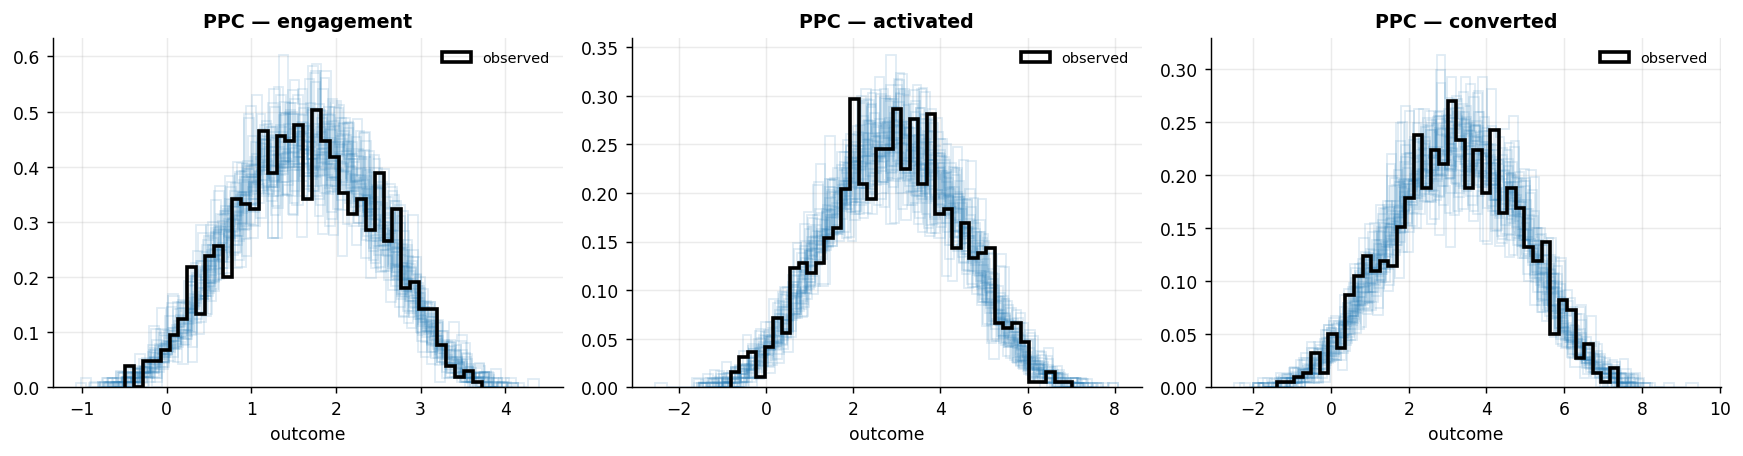

In [7]:
pp = m.predict(progressbar=False)   # posterior-predictive replicates of every endogenous stage, from the fitted chain
rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
cov_share = {}
for a, v in zip(ax, ["engagement", "activated", "converted"]):
    rep = pp.posterior_predictive[v].values.reshape(-1, len(df))
    sub = rep[rng.choice(rep.shape[0], size=min(400, rep.shape[0]), replace=False)]
    y_obs = df[v].values
    plots.ppc_plot(a, y_obs, sub[:40], title=f"PPC — {v}")
    lo, hi = np.percentile(sub, [5, 95], axis=0)        # per-user 5-95% replicate band
    cov_share[v] = float(((y_obs >= lo) & (y_obs <= hi)).mean())
fig.tight_layout()
print("Share of observed values inside the replicates' per-user 5-95% band (~90% if calibrated):  "
      + "  ·  ".join(f"{v}: {c:.0%}" for v, c in cov_share.items()))
print("No gross misfit in any stage equation -- safe to read path effects off this model."
      if all(0.82 <= c <= 0.98 for c in cov_share.values())
      else "At least one stage equation misfits -- fix the model before trusting any path product.")

**Real-data check + the naive-regression trap.** Before trusting the split: (a) do the funnel **DAG**'s (directed acyclic graph — the arrows-only causal diagram) own testable implications survive on this data — each reported below as a **partial correlation** (the correlation left between two variables after removing the conditioning set), and (b) what would a *naive* controlled regression — onboarding **plus** the mediators, all in one OLS — report for onboarding? The path queries above need neither trick; the naive regression, as the numbers show, misreads onboarding's total effect.

In [8]:
# (a) Falsify the funnel DAG against the data: does the graph survive its own implied independences?
# At alpha=0.05 each test still rejects ~5% of the time even when the graph is CORRECT, so the number of
# violations ~ Binomial(n_tests, 0.05). We read the count against that false-positive budget -- a lone
# marginal rejection among several tests is expected noise, not evidence against the graph (approximate:
# it assumes the tests are independent) -- rather than treating any single violation as fatal.
from scipy.stats import binom
imp = m.test_implications(alpha=0.05)
p_chance = float(binom.sf(imp.n_violations - 1, imp.n_tests, 0.05))   # P(>= this many rejections by chance)
verdict = 'graph survives falsification' if p_chance > 0.05 else 'graph is contradicted by the data'
print(f"Testable implications of the funnel DAG: {imp.n_tests} checked -> {imp.n_violations} violated; "
      f"P(>={imp.n_violations} by chance at alpha=0.05) = {p_chance:.2f} ({verdict}).")
for _, t in imp.results[imp.results.significant].iterrows():   # name the flagged test, don't leave it a mystery
    print(f"  the flagged independence: {t.x} ⊥ {t.y} | {{{t.conditioning_set}}}  "
          f"(partial corr {t.partial_corr:+.3f}, p = {t.p_value:.3f}) — in this simulation every implied "
          f"independence holds by construction, so this is a knowable false positive, exactly what the "
          f"Binomial budget above prices in.")

# (b) The naive-regression trap: regress converted on onboarding AND the mediators together in one OLS.
Xn = np.column_stack([np.ones(len(df)), df['onboarding_score'].values,
                      df['engagement'].values, df['activated'].values])
beta_naive = np.linalg.lstsq(Xn, df['converted'].values, rcond=None)[0]
on_coef = beta_naive[1]
print(f"Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = {on_coef:+.3f}  "
      f"(vs TRUE total {true_effects['total']:.2f}).")
print(f"Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the "
      f"leftover DIRECT effect, not the total). That is exactly why a naive controlled regression MISreads "
      f"onboarding's real leverage -- and why the path decomposition above, not OLS, is what you need.")

Testable implications of the funnel DAG: 3 checked -> 1 violated; P(>=1 by chance at alpha=0.05) = 0.14 (graph survives falsification).
  the flagged independence: channel_quality ⊥ onboarding_score | {}  (partial corr +0.087, p = 0.006) — in this simulation every implied independence holds by construction, so this is a knowable false positive, exactly what the Binomial budget above prices in.
Naive OLS  converted ~ onboarding + engagement + activated : onboarding coef = +0.059  (vs TRUE total 3.94).
Putting the mediators in the regression collapses onboarding's coefficient toward ~0 (it now reads only the leftover DIRECT effect, not the total). That is exactly why a naive controlled regression MISreads onboarding's real leverage -- and why the path decomposition above, not OLS, is what you need.


## 5 · Validate — recover the total, the paths, the DIRECT effect, and the proportion mediated

We query four things and check each against the planted truth: the **total** effect of onboarding on
conversion; the effect flowing through each **path**; the **direct** (natural direct) effect — which the
model is now free to find, and which should come out **≈ 0** if onboarding really works only through the
funnel; and the **proportion mediated** (indirect ÷ total). A proportion near 100% *with a direct effect
whose interval includes 0* is the honest version of "onboarding works almost entirely by feeding the rest
of the funnel" — a very different investment story from a direct effect.

Recovery on one dataset is necessary, not sufficient — so Step 5 closes with two harder checks:
a **replication across fresh simulations** (is the recovery calibrated, or a lucky seed?) and a
**fail → fix** refit that deliberately drops the mediators' common driver to show what unmeasured
mediator confounding actually does to the split.

In [9]:
def get_draws(res):
    d = res.draws
    return np.asarray(d() if callable(d) else d)

total_d = get_draws(m.ate("converted", "onboarding_score"))
direct_d = get_draws(m.effect("onboarding_score -> converted"))          # NDE (should be ~ 0)
via_act = get_draws(m.effect("onboarding_score -> engagement -> activated -> converted"))
via_eng = get_draws(m.effect("onboarding_score -> engagement -> converted"))
indirect_d = via_act + via_eng
prop_mediated = indirect_d / total_d

def line(lbl, d, truth):
    print(f"{lbl:38s} {d.mean():5.2f}  (true {truth:.2f})  [90% {np.quantile(d,.05):.2f}, {np.quantile(d,.95):.2f}]")
line("TOTAL onboarding -> converted", total_d, true_effects['total'])
line("  DIRECT (NDE) onboarding -> converted", direct_d, 0.0)
line("  via engagement->activated->conv", via_act, true_effects['indirect_via_engagement_activated'])
line("  via engagement->converted", via_eng, true_effects['indirect_via_engagement_only'])
pm_lo, pm_hi = np.quantile(prop_mediated, [.05, .95])
print(f"Proportion mediated (indirect / total): {prop_mediated.mean():.0%}   [90% {pm_lo:.0%}, {pm_hi:.0%}]")
print(f"The DIRECT effect's 90% interval includes 0, so the ~{prop_mediated.mean():.0%} proportion mediated is "
      f"DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.")

TOTAL onboarding -> converted           3.92  (true 3.94)  [90% 3.76, 4.08]
  DIRECT (NDE) onboarding -> converted  0.06  (true 0.00)  [90% -0.03, 0.15]
  via engagement->activated->conv       3.14  (true 3.17)  [90% 2.96, 3.31]
  via engagement->converted             0.72  (true 0.77)  [90% 0.56, 0.89]
Proportion mediated (indirect / total): 98%   [90% 96%, 101%]
The DIRECT effect's 90% interval includes 0, so the ~98% proportion mediated is DISCOVERED — the model was free to find a direct onboarding->conversion path and the data say there isn't one.


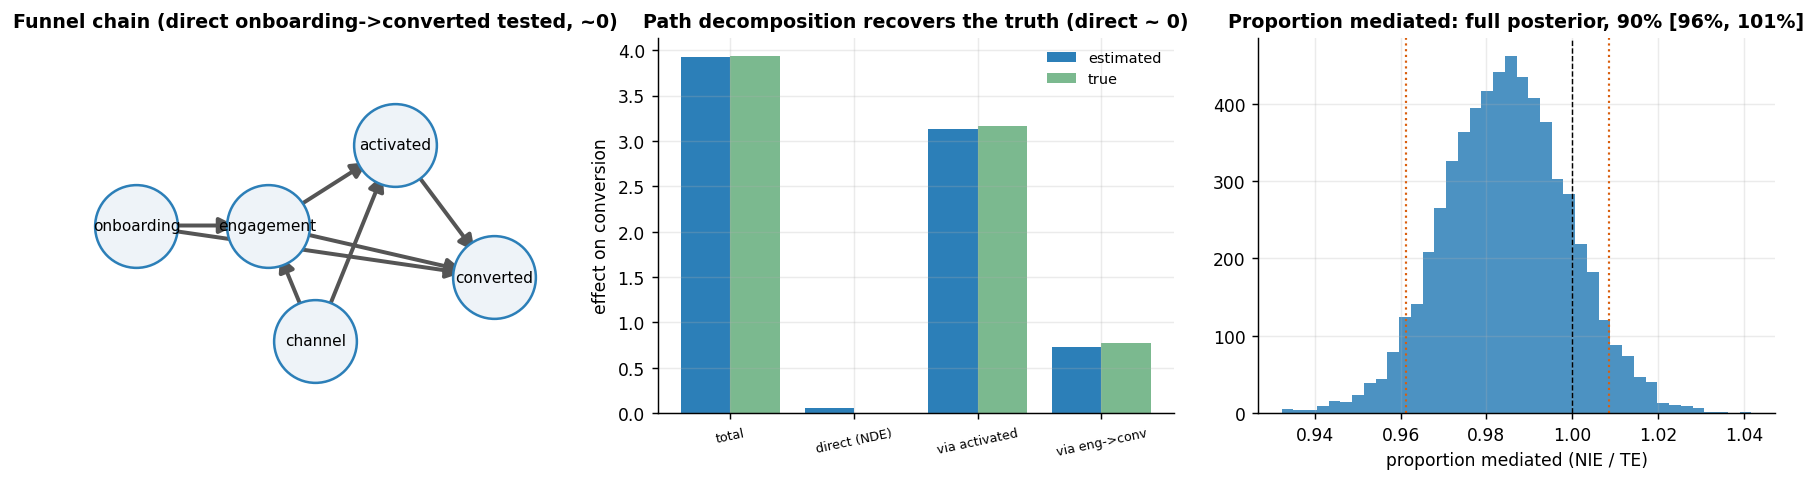

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
pos = {"onboarding": (0.05,0.5), "engagement": (0.38,0.5), "activated": (0.7,0.78), "converted": (0.95,0.32), "channel": (0.5,0.1)}
edges = [("onboarding","engagement"),("engagement","activated"),("activated","converted"),
         ("engagement","converted"),("onboarding","converted"),   # onboarding->converted is TESTED (comes out ~0)
         ("channel","engagement"),("channel","activated")]
plots.draw_dag(ax[0], pos, edges, title="Funnel chain (direct onboarding->converted tested, ~0)")
labels = ["total","direct (NDE)","via activated","via eng->conv"]
means = [total_d.mean(), direct_d.mean(), via_act.mean(), via_eng.mean()]
truths_bar = [true_effects['total'], 0.0, true_effects['indirect_via_engagement_activated'], true_effects['indirect_via_engagement_only']]
x = np.arange(len(labels))
ax[1].bar(x-0.2, means, 0.4, color=plots.BLUE, label="estimated")
ax[1].bar(x+0.2, truths_bar, 0.4, color=plots.GREEN, alpha=0.6, label="true")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=7, rotation=12); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_ylabel("effect on conversion"); ax[1].set_title("Path decomposition recovers the truth (direct ~ 0)")
ax[2].hist(prop_mediated, bins=40, color=plots.BLUE, alpha=0.85)
ax[2].axvline(1.0, color="k", ls="--", lw=0.8)
for q in (pm_lo, pm_hi): ax[2].axvline(q, color=plots.ORANGE, ls=":", lw=1.2)
ax[2].set_xlabel("proportion mediated (NIE / TE)")
ax[2].set_title(f"Proportion mediated: full posterior, 90% [{pm_lo:.0%}, {pm_hi:.0%}]")
fig.tight_layout()

**How to read this.** *Left* is the causal graph we fit — including a **direct** onboarding→conversion
arrow, which we deliberately added so the model could find a direct effect if one existed. *Middle* —
the estimated total and each path effect (blue) sit on top of the planted truths (green), and the
**direct (NDE) bar is ≈ 0** (its interval includes zero): onboarding works almost entirely *through*
the funnel, and that near-100%-mediated result is now **discovered, not assumed**. *Right* — the
proportion mediated as a **full posterior** with its 90% interval, because "~100% mediated" is a
headline number people will quote and it should carry uncertainty like everything else (the dashed
line at 1.0 is "fully mediated"; draws land on either side of it because both NIE and TE are noisy).
This is the decomposition a naive "regress conversion on each stage" analysis cannot give you.

### Not a lucky seed — replication on fresh simulated worlds

Everything above is one dataset from one seed. A method that recovers the truth once might be
benefiting from friendly noise, and its intervals might be too tight (they'd then miss the truth on
other draws more than 10% of the time). So we redraw the world from the same DGP several times,
refit with deliberately short chains (posterior *means and intervals* are all we grade), and check
two things per quantity: **bias** (do the estimates center on the truth?) and **90%-interval
coverage** (do the intervals contain it about 90% of the time?). Because the four path quantities are all read off the *same* fit, they do not fail independently: an unlucky dataset tends to shift them together, so any misses cluster on a seed rather than scattering one-by-one across the table.

In [11]:
REP_SEEDS = 4 if FAST else 8
REP_FIT = dict(draws=200, tune=200, chains=2, cores=1) if FAST else dict(draws=300, tune=300, chains=2, cores=1)
truths = {"total": true_effects["total"], "direct": 0.0,
          "via_act": true_effects["indirect_via_engagement_activated"],
          "via_eng": true_effects["indirect_via_engagement_only"]}
rows = []
for s in range(REP_SEEDS):
    dfs, _ = dgp.funnel(n=1000, seed=100 + s)
    ms = pathmc.model(spec, data=dfs)
    ms.fit(random_seed=100 + s, progressbar=False, **REP_FIT)
    q = {"total": get_draws(ms.ate("converted", "onboarding_score")),
         "direct": get_draws(ms.effect("onboarding_score -> converted")),
         "via_act": get_draws(ms.effect("onboarding_score -> engagement -> activated -> converted")),
         "via_eng": get_draws(ms.effect("onboarding_score -> engagement -> converted"))}
    row = {"seed": 100 + s}
    for k, d in q.items():
        lo, hi = np.quantile(d, [.05, .95])
        row[k] = d.mean()
        row[k + "_ok"] = bool(lo <= truths[k] <= hi)     # did the 90% interval cover the planted truth?
    rows.append(row)
stab = pd.DataFrame(rows)
print("planted truth:   " + "   ".join(f"{k} = {v:.2f}" for k, v in truths.items()) + "\n")
disp = stab[["seed"]].copy()
for k in truths:
    disp[k] = [f"{m:.2f} {'ok' if o else 'MISS'}" for m, o in zip(stab[k], stab[k + '_ok'])]
print(disp.to_string(index=False))
print("(cell = posterior mean + 90%-interval coverage of the planted truth)")
ok_cols = [k + "_ok" for k in truths]
n_cov, n_int = int(stab[ok_cols].values.sum()), int(stab[ok_cols].size)
bias = {k: float(stab[k].mean() - truths[k]) for k in truths}
print(f"\n{len(truths)} quantities x {REP_SEEDS} fresh simulations -> {n_int} 90% intervals, {n_cov} covered "
      f"({n_cov / n_int:.0%}; ~90% is calibrated).  Mean bias: "
      + "  ".join(f"{k} {bias[k]:+.2f}" for k in truths) + ".")
print("Recovery is consistent across seeds -- Step 5's numbers are calibrated, not a lucky draw."
      if n_cov / n_int >= 0.75 else
      "Coverage falls short of nominal on these seeds -- treat the Step-5 intervals as optimistic.")

planted truth:   total = 3.94   direct = 0.00   via_act = 3.17   via_eng = 0.77

 seed     total    direct   via_act   via_eng
  100   3.93 ok   0.02 ok   3.26 ok   0.65 ok
  101   4.02 ok  -0.03 ok   3.34 ok   0.71 ok
  102   3.84 ok  -0.00 ok   3.11 ok   0.73 ok
  103   3.90 ok   0.01 ok   3.22 ok   0.66 ok
  104   3.97 ok  -0.01 ok   3.19 ok   0.78 ok
  105 4.10 MISS 0.11 MISS 3.40 MISS 0.59 MISS
  106   4.03 ok  -0.04 ok   3.19 ok   0.88 ok
  107   3.94 ok  -0.05 ok   3.11 ok   0.89 ok
(cell = posterior mean + 90%-interval coverage of the planted truth)

4 quantities x 8 fresh simulations -> 32 90% intervals, 28 covered (88%; ~90% is calibrated).  Mean bias: total +0.03  direct +0.00  via_act +0.06  via_eng -0.03.
Recovery is consistent across seeds -- Step 5's numbers are calibrated, not a lucky draw.


### Fail → fix: drop the mediators' common driver and watch the split break

Step 3 warned that with two ordered mediators, an **unmeasured confounder between the mediators**
poisons the path decomposition — and this DGP hands us the perfect prop: `channel_quality` feeds
*both* engagement and activation. So far we have always adjusted for it. Now we refit the same chain
**with every `channel_quality` term deleted**, exactly as if the growth team had never logged
acquisition channel — the single most realistic way this analysis goes wrong in production.

What should happen, mechanically: with $Q$ gone, the engagement→activated edge **absorbs $Q$'s
effect on activation** (users on good channels are both more engaged and more activated, and the
model can only route that association through `a_eng`), so `a_eng` overshoots its planted 1.6 —
and every path product built on that edge (the long path, and the graph-computed total that sums
the paths) inherits the bias. Meanwhile a plain OLS of conversion on onboarding *alone* stays
honest, because onboarding itself is exogenous here (nothing feeds into it) — which is precisely
the opening cell's claim, now with numbers: **unmeasured mediator confounding breaks the split
(and everything computed from it) even when the raw total effect of the treatment is fine.**
And the DAG falsification test from Step 4 — which on the correct graph only ever produced a
priced-in false positive — should now catch a **true** violation. Read the printed output below
against each prediction.

In [12]:
spec_bad = '''
engagement ~ e_on*onboarding_score
activated  ~ a_eng*engagement
converted  ~ c_act*activated + c_eng*engagement + c_on*onboarding_score
'''
m_bad = pathmc.model(spec_bad, data=df)          # same data; the model just cannot SEE channel_quality
m_bad.fit(random_seed=SEED, progressbar=False, cores=1, **FIT)
bad = {"total": get_draws(m_bad.ate("converted", "onboarding_score")),
       "direct": get_draws(m_bad.effect("onboarding_score -> converted")),
       "via_act": get_draws(m_bad.effect("onboarding_score -> engagement -> activated -> converted")),
       "via_eng": get_draws(m_bad.effect("onboarding_score -> engagement -> converted"))}
good = {"total": total_d, "direct": direct_d, "via_act": via_act, "via_eng": via_eng}
rows = []
for k in bad:
    glo, ghi = np.quantile(good[k], [.05, .95]); blo, bhi = np.quantile(bad[k], [.05, .95])
    rows.append({"quantity": k, "truth": truths[k],
                 "with Q": good[k].mean(), "with Q covers": bool(glo <= truths[k] <= ghi),
                 "no Q": bad[k].mean(), "no Q covers": bool(blo <= truths[k] <= bhi)})
cmp_tbl = pd.DataFrame(rows)
print(cmp_tbl.round(2).to_string(index=False))
a_bad = float(m_bad.effects_summary().loc["a_eng", "mean"])
n_miss = int((~cmp_tbl["no Q covers"]).sum())
print(f"\nWith channel_quality dropped, eng->act absorbs Q's effect: a_eng = {a_bad:.2f} vs planted 1.60 -- and "
      f"{n_miss} of 4 'no Q' 90% intervals now miss the truth (vs {int((~cmp_tbl['with Q covers']).sum())} of 4 with Q).")

# The raw total from regressing converted on onboarding ALONE is still fine: onboarding is exogenous
# (no arrow points into it), so omitting Q poisons the path SPLIT, not the treatment's raw total.
Xm = np.column_stack([np.ones(len(df)), df["onboarding_score"].values])
bm, res = np.linalg.lstsq(Xm, df["converted"].values, rcond=None)[:2]
se = float(np.sqrt(res[0] / (len(df) - 2) / ((df["onboarding_score"] - df["onboarding_score"].mean())**2).sum()))
zm = abs(float(bm[1]) - truths["total"]) / se
print(f"Plain OLS converted ~ onboarding alone: {bm[1]:.2f} (SE {se:.2f}) vs true {truths['total']:.2f} -- "
      f"{'consistent with the truth' if zm < 2 else 'off from the truth'} ({zm:.1f} SE away). The split is what "
      f"breaks; the raw total was never in danger.")

# The graph's own falsification now catches the misspecification -- a TRUE positive this time.
imp_bad = m_bad.test_implications(alpha=0.05)
print(f"\ntest_implications on the no-Q graph: {imp_bad.n_tests} test(s) -> {imp_bad.n_violations} violated"
      + (":" if imp_bad.n_violations else " (nothing flagged)."))
for _, t in imp_bad.results[imp_bad.results.significant].iterrows():
    print(f"  {t.x} ⊥ {t.y} | {{{t.conditioning_set}}} FAILS (partial corr {t.partial_corr:+.3f}, p = {t.p_value:.1e}) "
          f"-- the unmeasured mediator confounder leaves a testable footprint; the Step-4 falsification "
          f"cell is not decoration, it catches exactly this misspecification.")

quantity  truth  with Q  with Q covers  no Q  no Q covers
   total   3.94    3.92           True  4.29        False
  direct   0.00    0.06           True  0.06         True
 via_act   3.17    3.14           True  3.47        False
 via_eng   0.77    0.72           True  0.76         True

With channel_quality dropped, eng->act absorbs Q's effect: a_eng = 1.71 vs planted 1.60 -- and 2 of 4 'no Q' 90% intervals now miss the truth (vs 0 of 4 with Q).
Plain OLS converted ~ onboarding alone: 4.13 (SE 0.13) vs true 3.94 -- consistent with the truth (1.5 SE away). The split is what breaks; the raw total was never in danger.

test_implications on the no-Q graph: 1 test(s) -> 1 violated:
  activated ⊥ onboarding_score | {engagement} FAILS (partial corr -0.184, p = 5.1e-09) -- the unmeasured mediator confounder leaves a testable footprint; the Step-4 falsification cell is not decoration, it catches exactly this misspecification.


### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

In [13]:
# --- 5x · Step 0's classical decomposition vs the posterior, on the SAME four estimands ---------------
post = {"total": total_d, "direct": direct_d, "via_act": via_act, "via_eng": via_eng}
print("SAME estimands (§3's NDE/NIE), SAME assumptions (SI-1..SI-4), two apparatuses.")
print(f"CLASSICAL = plug-in products of OLS coefficients, {N_BOOT}-resample bootstrap CI.")
print("BAYESIAN  = posterior mean of the path products, 90% credible interval.\n")
print(f"{'':24}{'--- CLASSICAL ---':>23}{'--- BAYESIAN ---':>23}{'':>7}")
print(f"{'quantity':24}{'est':>6}{'90% CI':>17}{'mean':>6}{'90% CrI':>17}{'truth':>7}")
gaps, widths = [], []
for k in KEYS:
    r, d = cl_paths[k], post[k]
    plo, phi = np.quantile(d, [.05, .95])
    print(f"{NAMES[k]:24}{r.estimate:>6.2f}{f'[{r.ci[0]:.2f}, {r.ci[1]:.2f}]':>17}"
          f"{d.mean():>6.2f}{f'[{plo:.2f}, {phi:.2f}]':>17}{TRUTHS[k]:>7.2f}")
    gaps.append(abs(r.estimate - d.mean()))
    widths.append((phi - plo) / (r.ci[1] - r.ci[0]))
plo, phi = np.quantile(prop_mediated, [.05, .95])
print(f"{'proportion mediated':24}{cl_prop.estimate:>6.0%}"
      f"{f'[{cl_prop.ci[0]:.0%}, {cl_prop.ci[1]:.0%}]':>17}{prop_mediated.mean():>6.0%}"
      f"{f'[{plo:.0%}, {phi:.0%}]':>17}{1.0:>7.0%}")
print(f"\nLOCATION -- they agree, and not approximately: the largest gap between a")
print(f"  classical plug-in and its posterior mean is {max(gaps):.3f}, on effects of size "
      f"~{TRUTHS['total']:.1f}.")
print(f"  With n = {len(df):,} and N(0,10) priors on coefficients of order 1, the")
print("  likelihood IS the posterior, and OLS sits at its mode.")
print("WIDTH -- they agree too. posterior CrI width / bootstrap CI width:")
print("  " + ",  ".join(f"{k} {w:.2f}" for k, w in zip(KEYS, widths)) + ".")

# --- The SI-2 violation, run through BOTH arms -------------------------------------------------------
# The fail->fix above refit the BAYESIAN chain with channel_quality deleted. Do the identical thing to the
# CLASSICAL arm: drop channel_quality from the two stage regressions (use_Q=False) and re-multiply.
cl_bad = path_products(df, use_Q=False)
print("\nTHE FAIL->FIX, IN BOTH ARMS -- the SI-2 violation of §5, run through both:")
print("refit with channel_quality unobserved (the driver of BOTH mediators).")
print(f"{'quantity':26}{'truth':>7}{'classical':>11}{'Bayesian':>10}{'both off by':>14}")
for i, k in enumerate(KEYS):
    print(f"{NAMES[k]:26}{TRUTHS[k]:>7.2f}{cl_bad[i]:>11.2f}{bad[k].mean():>10.2f}"
          f"{cl_bad[i] - TRUTHS[k]:>+14.2f}")
print(f"  -> classical and Bayesian bias agree to {max(abs(cl_bad[i] - bad[k].mean()) for i, k in enumerate(KEYS)):.3f} units:")
print("     the SAME violation, the SAME wrong answer, out of both apparatuses.")
print("     A prior cannot see an unmeasured confounder; neither can a bootstrap.")

# --- What only a posterior can say: probabilities ABOUT the effects -----------------------------------
print("\nDECISION QUANTITIES — probabilities about the effects themselves:")
q = {"P(indirect > direct)": float((indirect_d > direct_d).mean()),
     "P(proportion mediated > 90%)": float((prop_mediated > 0.90).mean()),
     "P(direct effect > 0.25)": float((direct_d > 0.25).mean())}
print(f"  {'':32}{'classical':>13}{'Bayesian':>11}")
for lbl, p in q.items():
    print(f"  {lbl:32}{'not defined':>13}{p:>11.2f}")
print("  ('not defined' is not a dodge: a confidence interval attaches no")
print("   probability to a hypothesis about a fixed parameter. §6's P(ROI>1)")
print("   and its break-even cost-ratio posterior are the same species of")
print("   quantity -- and they are what finance actually asked for.)")

SAME estimands (§3's NDE/NIE), SAME assumptions (SI-1..SI-4), two apparatuses.
CLASSICAL = plug-in products of OLS coefficients, 2000-resample bootstrap CI.
BAYESIAN  = posterior mean of the path products, 90% credible interval.

                              --- CLASSICAL ---       --- BAYESIAN ---       
quantity                   est           90% CI  mean          90% CrI  truth
TOTAL onboarding->conv    3.92     [3.77, 4.07]  3.92     [3.76, 4.08]   3.94
DIRECT (NDE)              0.06    [-0.03, 0.15]  0.06    [-0.03, 0.15]   0.00
indirect eng->act->conv   3.13     [2.97, 3.31]  3.14     [2.96, 3.31]   3.17
indirect eng->conv        0.72     [0.57, 0.88]  0.72     [0.56, 0.89]   0.77
proportion mediated        98%      [96%, 101%]   98%      [96%, 101%]   100%

LOCATION -- they agree, and not approximately: the largest gap between a
  classical plug-in and its posterior mean is 0.002, on effects of size ~3.9.
  With n = 1,000 and N(0,10) priors on coefficients of order 1, the
  li

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They agree, and it is not close.** Read the location line in the print-out. The classical plug-in
products and the posterior means land on top of each other — a gap of a few thousandths on effects of
size ~3.9 — and the bootstrap confidence intervals and the credible intervals agree to within a cent or two
on every bound, their widths agreeing to within the few percent printed on the WIDTH line. That is not luck and it is not disappointing: it is what *must* happen with $n=1{,}000$,
weak priors and a linear Gaussian SCM, where the posterior is the likelihood and OLS sits at its mode.
The two arms are **the same estimator wearing different clothes**. Say it plainly: on this data,
**the Bayesian machinery did not move the number, and it did not sharpen the interval.** If you came
here expecting mediation to be a place where Bayes rescues the estimate, this table is the correction.

**2 · What Bayes did *not* buy — and this is the important one.** It did not buy protection from
**SI-2**. The fail → fix block above deletes `channel_quality` — the driver of *both* mediators — and
refits; §5's table showed the Bayesian split breaking. The 5x print-out adds the sentence the notebook
owes you: **the classical arm breaks in exactly the same direction, by exactly the same amount**, to two
decimals. Of course it does. Both arms fit the same edges under the same assumption; an unmeasured
mediator–outcome confounder is not a statement about sampling variability, and *nothing in either
apparatus is looking for it*. A prior cannot see it. A bootstrap cannot see it — resampling the rows
re-estimates the same biased quantity a thousand times and reports, very precisely, how stable the bias
is. This is the whole reason §3's assumption list is not decoration and §6's sensitivity sweep is not
optional: in mediation, **the dominant uncertainty is not in the interval at all**, and both apparatuses
will hand you a tight one around a confounded number with the same untroubled face.

**3 · What the posterior *does* buy — four things, all of them real.**

- **The product carries its uncertainty exactly.** The NIE is $a\!\cdot\!b$, a product of correlated
  parameters. The classical arm needs a *device* for that — the delta method (first-order, and it fails
  when a link is weak) or a bootstrap (an approximation to the sampling distribution, and 2,000 refits).
  A joint posterior over $(a,b,c)$ needs no device: multiply the draws. The uncertainty in the product is
  simply the uncertainty in the factors, propagated — for free, and correctly, including when $\hat a$ is
  small. Step 0's own printout shows the bootstrap and the delta method agreeing *here*; the posterior is
  the arm that does not have to check.
- **Derived quantities are just functions of draws.** The **proportion mediated** is a *ratio* of two
  quantities estimated from the same fit and correlated with each other; §6's **break-even cost ratio**
  is a ratio of two lever values; §5's replication grades intervals on all four path effects at once.
  Each is one line of arithmetic on the posterior draws, with a coherent interval falling out. Classically
  each is another bespoke bootstrap, and their intervals do not have to cohere with one another.
- **The sensitivity analysis becomes a posterior, not a point.** §6's sweep does not ask "what if the
  engagement → conversion edge were 30% confounded?" once, with the fitted point estimate. It asks it
  **per draw**, so the flip point — the confounding share at which the engagement-vs-activation ranking
  reverses — comes back as a *distribution with a 90% interval*, and it shrinks both affected levers
  together because they ride the same edge. That is the coherence a joint posterior gives you and a
  collection of separate bootstraps does not.
- **The decision quantities in §6 exist at all.** `P(ROI > 1)`, `P(engagement beats activated per SD)`,
  the break-even cost ratio's interval, and the `P(indirect > direct)` printed above — every one of them
  is a probability *about the effect*, and the classical column reads **not defined** for all of them.
  That is not a rhetorical concession, it is the literal state of the frequentist apparatus: it has no
  probability to attach to a hypothesis about a fixed parameter. And note the trap that makes this
  sharper than it looks: you *can* bootstrap the proportion mediated (Step 0 did), and you will get an
  interval — but the share of bootstrap replicates above 90% is **not** $P(\text{prop mediated} > 90\%)$.
  It is the frequency with which a *resampled estimate* exceeds 90%, a statement about the estimator's
  wobble, not about the world. §6's budget rule needs the latter.

> **The ledger, in one line.** Bayes bought the euro decision in §6 — the probabilities, the coherent
> ratios, the sweep with bands — and bought nothing at all on the estimate, the interval, or the
> assumption. In a chapter about mediation that last clause is the one to remember: **the hard part was
> never the arithmetic, and no amount of machinery on either side of the aisle will buy you SI-2.** Only
> a better measurement will — which is exactly why §8's recommended follow-up is an experiment that
> *randomises onboarding and logs the mediators*, not a fancier model.

## 6 · Decide, in euros — a *rankable* leverage metric, its intervals, and its fragility

Three moves, and each corrects a trap.

**(1) Rank the levers — but not by "€ per one-unit change."** A one-unit move means something completely
different per stage (one unit of `onboarding_score` is a large fraction of its whole range; one unit of
`activated` is a fraction of a standard deviation), so a €/unit ranking is not a rankable quantity — it
*reverses* when you switch to comparable **per-standard-deviation** moves. The decision-relevant metric is
**ROI = (€ value of a 1-SD lift) ÷ (€ cost to produce that 1-SD lift)** — and every € number below
carries its **90% credible interval** (table + forest plot), because a ranking whose intervals overlap
is a preference, not a decision.

**(2) Turn the stated cost into a break-even rule.** "Equal €100 per SD for every stage" is an
illustration, not a fact — real per-stage costs are what the promise of a *budget split* hinges on. So
instead of betting on one cost number, we report the **posterior break-even cost ratio** for each pair
of levers: lever A beats lever B on ROI exactly when $\text{cost}_A/\text{cost}_B <
\text{value}_A/\text{value}_B$, and the right-hand side is a posterior we already have. Hand the rule
to finance: they measure the cost ratio, the posterior says who wins — with uncertainty attached.

**(3) Stress-test the split — coherently.** The decomposition rests on *no unmeasured mediator–outcome
confounding* (SI-2). A confounder of engagement→conversion biases the fitted edge — but that same edge
carries **both** the engagement lever **and** onboarding's total effect, so an honest sweep must shrink
them *together* (a common mistake is to bias one and freeze the other). We do that per posterior draw —
so the sweep has **bands**, and the "flip point" is a posterior with an interval, not a single number.

     lever  €/unit  €/SD €/SD 90% CrI  ROI (€/€)  P(ROI>1)
engagement     215   176   [172, 180]       1.76       1.0
 activated     108   159   [152, 165]       1.59       1.0
onboarding     470   133   [128, 139]       1.33       1.0

Per-UNIT vs per-SD DISAGREE: a 1-SD onboarding move is only 0.28 units (tiny) while a 1-SD activated move is 1.47 units (large), so €/unit is not rankable -- use ROI on a stated cost. At equal €100/SD the order is engagement > activated > onboarding; all three clear break-even at the stated cost.
Sampling-noise decisiveness of the eng>act gap: P(engagement > activated per SD) = 1.00 (1.00 = no overlap, ordering certain up to sampling).
Break-even rules: onboarding beats engagement on ROI once a 1-SD onboarding lift costs less than 0.76x a 1-SD engagement lift (90% [0.72, 0.79]); for activated the break-even cost ratio vs engagement is 0.90x (90% [0.86, 0.95]).


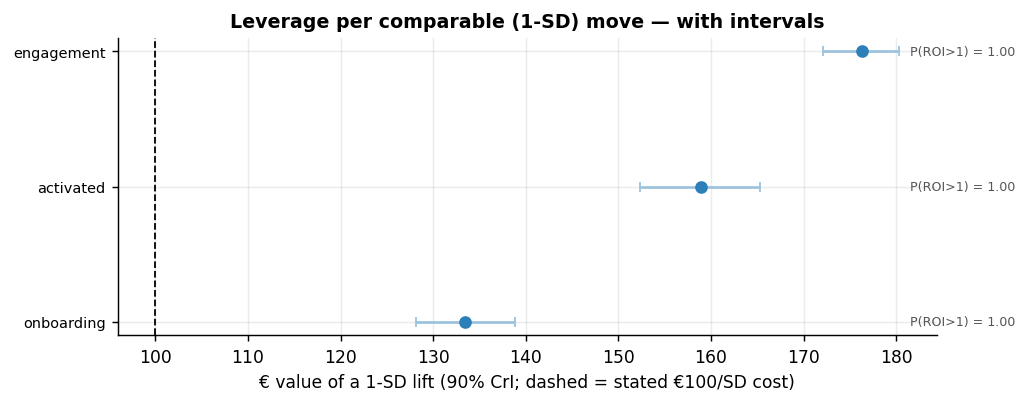

In [14]:
VALUE = 120.0
sd = {"onboarding": df.onboarding_score.std(), "engagement": df.engagement.std(), "activated": df.activated.std()}
eff = {"onboarding": total_d,
       "engagement": get_draws(m.ate("converted", "engagement")),
       "activated":  get_draws(m.ate("converted", "activated"))}
val = {k: eff[k] * sd[k] * VALUE for k in eff}            # posterior draws of the € value of a 1-SD lift
COST_SD = 100.0                                           # € to move any stage by 1 SD (STATED, illustrative)
roi = {k: val[k] / COST_SD for k in eff}
cri = {k: np.quantile(val[k], [.05, .95]) for k in eff}
tbl = pd.DataFrame({
    "lever": list(eff),
    "€/unit": [round(eff[k].mean() * VALUE) for k in eff],   # 1) unit-dependent -- NOT rankable
    "€/SD": [round(val[k].mean()) for k in eff],             # 2) comparable magnitudes
    "€/SD 90% CrI": [f"[{cri[k][0]:.0f}, {cri[k][1]:.0f}]" for k in eff],
    "ROI (€/€)": [round(roi[k].mean(), 2) for k in eff],
    "P(ROI>1)": [round((roi[k] > 1).mean(), 2) for k in eff],
}).sort_values("€/SD", ascending=False)
print(tbl.to_string(index=False))

p_eng_act = float((val["engagement"] > val["activated"]).mean())
minp = min(float((roi[k] > 1).mean()) for k in eff)
print(f"\nPer-UNIT vs per-SD DISAGREE: a 1-SD onboarding move is only {sd['onboarding']:.2f} units (tiny) while a "
      f"1-SD activated move is {sd['activated']:.2f} units (large), so €/unit is not rankable -- use ROI on a stated "
      f"cost. At equal €{COST_SD:.0f}/SD the order is {' > '.join(tbl['lever'])}; "
      + ("all three clear break-even at the stated cost." if minp > 0.9 else "not every lever clears break-even."))
print(f"Sampling-noise decisiveness of the eng>act gap: P(engagement > activated per SD) = {p_eng_act:.2f} (1.00 = no overlap, ordering certain up to sampling).")

# Break-even cost ratios: lever A beats lever B on ROI iff cost_A/cost_B < value_A/value_B (posterior).
be_onb_eng = val["onboarding"] / val["engagement"]
be_act_eng = val["activated"] / val["engagement"]
q_oe = np.quantile(be_onb_eng, [.05, .5, .95]); q_ae = np.quantile(be_act_eng, [.05, .5, .95])
print(f"Break-even rules: onboarding beats engagement on ROI once a 1-SD onboarding lift costs less than "
      f"{q_oe[1]:.2f}x a 1-SD engagement lift (90% [{q_oe[0]:.2f}, {q_oe[2]:.2f}]); for activated the break-even "
      f"cost ratio vs engagement is {q_ae[1]:.2f}x (90% [{q_ae[0]:.2f}, {q_ae[2]:.2f}]).")

fig, ax = plt.subplots(figsize=(8.0, 3.2))
order = list(tbl["lever"])
plots.forest_plot(ax, order, [float(val[k].mean()) for k in order],
                  [cri[k][0] for k in order], [cri[k][1] for k in order],
                  ref=COST_SD, xlabel="€ value of a 1-SD lift (90% CrI; dashed = stated €100/SD cost)",
                  title="Leverage per comparable (1-SD) move — with intervals",
                  annot=[f"P(ROI>1) = {(roi[k] > 1).mean():.2f}" for k in order])
fig.tight_layout()

**How to read the forest plot.** Every lever's €/SD value clears the stated €100 cost line with room
to spare, and `P(ROI>1)` saturates — which is itself informative: **sampling uncertainty is not the
binding risk here** (n=1000 and a linear SCM make these posteriors tight; the printed
P(engagement > activated) quantifies exactly how decisive the equal-cost ordering is on this data).
The intervals matter for the *break-even rules*: the posterior break-even ratios above are the
numbers to hand to finance, and their 90% intervals are what an honest budget memo quotes. What the
forest plot **cannot** show is assumption risk — the possibility that the engagement→conversion edge
itself is partly a hidden confounder's work. That is the sweep below, and it is where the ranking
actually becomes fragile.

The eng > act per-SD ordering flips once a hidden M-Y confounder explains ~52% of the fitted engagement->converted edge (90% [27%, 77%]); P(no flip within the whole edge) = 0.00.
Onboarding's TOTAL shrinks along the same sweep (it rides the same edge) but its story -- a root investment whose value is almost fully mediated -- survives; the fragile margin is engagement vs activated, and it should be quoted with its interval, never as a single flip percentage.


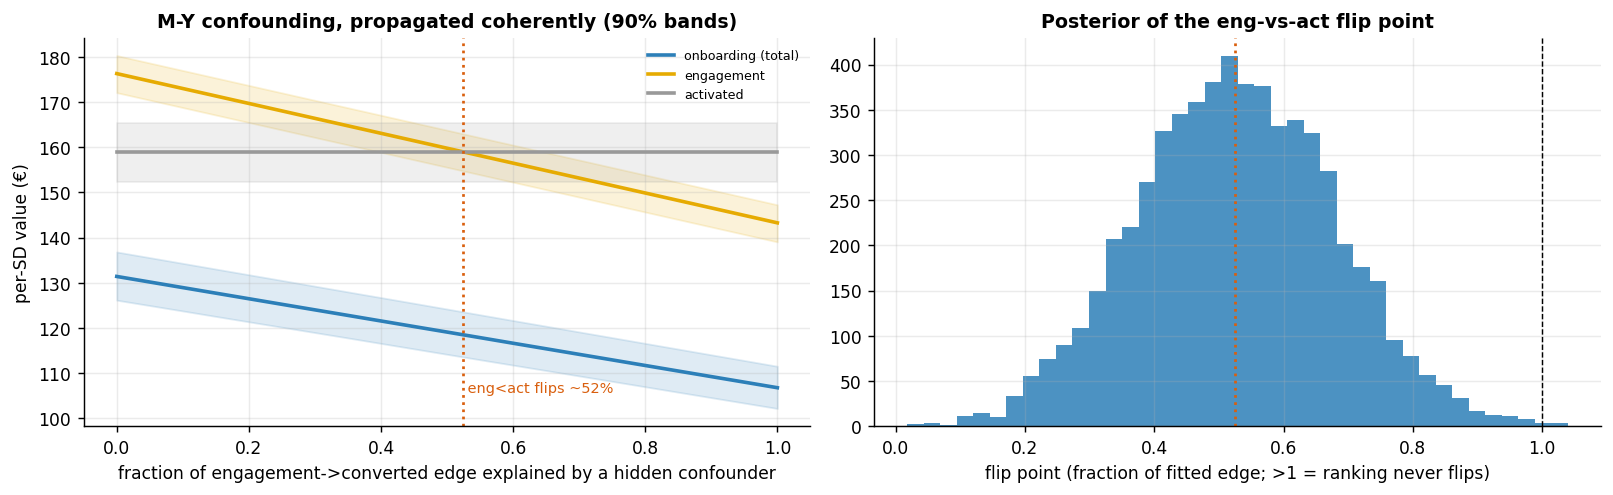

In [15]:
# Coherent M-Y sensitivity, now PER POSTERIOR DRAW: a hidden confounder of engagement->converted means
# the TRUE edge is (c_eng - b). That edge carries BOTH the engagement lever AND onboarding's total, so
# both shrink together along the sweep (biasing one and freezing the other would be incoherent).
c_eng = idata.posterior["beta_converted"].sel(converted_predictors="engagement").values.ravel()
c_act = idata.posterior["beta_converted"].sel(converted_predictors="activated").values.ravel()
a_eng = idata.posterior["beta_activated"].sel(activated_predictors="engagement").values.ravel()
e_on  = idata.posterior["beta_engagement"].sel(engagement_predictors="onboarding_score").values.ravel()
edge = abs(c_eng.mean()); bias_grid = np.linspace(0, edge, 21)

lever_eng = (c_eng[None, :] - bias_grid[:, None]) + (a_eng * c_act)[None, :]   # (bias, draw)
onb_d = e_on[None, :] * lever_eng * sd["onboarding"] * VALUE                   # onboarding total, €/SD
eng_d = lever_eng * sd["engagement"] * VALUE
act_d = np.broadcast_to((c_act * sd["activated"] * VALUE)[None, :], eng_d.shape)
qs = lambda arr: np.quantile(arr, [.05, .5, .95], axis=1)
onb_q, eng_q, act_q = qs(onb_d), qs(eng_d), qs(act_d)

# Per-draw flip point (closed form): eng's per-SD value equals act's at b* = c_eng + a_eng*c_act - c_act*sd_act/sd_eng.
b_star = c_eng + a_eng * c_act - c_act * sd["activated"] / sd["engagement"]
flip_frac = b_star / edge                                  # as a fraction of the fitted edge; >1 = never flips
f_lo, f_med, f_hi = np.quantile(flip_frac, [.05, .5, .95])
p_noflip = float((flip_frac > 1).mean())

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
xg = bias_grid / edge
for q, col, lbl in [(onb_q, plots.BLUE, "onboarding (total)"), (eng_q, plots.GOLD, "engagement"),
                    (act_q, plots.GREY, "activated")]:
    ax[0].plot(xg, q[1], color=col, lw=2, label=lbl)
    ax[0].fill_between(xg, q[0], q[2], color=col, alpha=0.15)
ax[0].axvline(f_med, color=plots.ORANGE, ls=":")
ax[0].text(f_med, float(eng_q[1].max()) * 0.6, f" eng<act flips ~{f_med:.0%}", fontsize=8, color=plots.ORANGE)
ax[0].set_xlabel("fraction of engagement->converted edge explained by a hidden confounder")
ax[0].set_ylabel("per-SD value (€)"); ax[0].set_title("M-Y confounding, propagated coherently (90% bands)")
ax[0].legend(frameon=False, fontsize=7)
ax[1].hist(np.clip(flip_frac, 0, 1.5), bins=40, color=plots.BLUE, alpha=0.85)
ax[1].axvline(1.0, color="k", ls="--", lw=0.8); ax[1].axvline(f_med, color=plots.ORANGE, ls=":")
ax[1].set_xlabel("flip point (fraction of fitted edge; >1 = ranking never flips)")
ax[1].set_title("Posterior of the eng-vs-act flip point")
fig.tight_layout()
print(f"The eng > act per-SD ordering flips once a hidden M-Y confounder explains ~{f_med:.0%} of the fitted "
      f"engagement->converted edge (90% [{f_lo:.0%}, {f_hi:.0%}]); P(no flip within the whole edge) = {p_noflip:.2f}.")
print("Onboarding's TOTAL shrinks along the same sweep (it rides the same edge) but its story -- a root "
      "investment whose value is almost fully mediated -- survives; the fragile margin is engagement vs "
      "activated, and it should be quoted with its interval, never as a single flip percentage.")

**How to read the sweep.** The bands are the posterior 90% intervals *at each level of hypothetical
confounding* — so the figure now separates the two kinds of uncertainty a decision-maker must not
conflate: the (narrow) sampling bands, and the (wide) horizontal question of *how much of the fitted
edge you believe*. The flip point itself is a posterior (right panel): quote its interval from the
printed line, not the median alone. If domain knowledge says hidden drivers of both engagement and
conversion (user intent, cohort quality) could plausibly account for a large share of that edge, the
engagement-vs-activated ranking should be treated as undecided — while onboarding's near-fully-mediated
total survives the same sweep with its story intact.

### The one-paragraph decision

> **What you tell the CMO.** Onboarding's conversion value is essentially **all mediated**
> (≈ 100%, with its 90% interval printed in Step 5): it is a *root* investment whose payoff lands two
> stages downstream, so judging it by direct/last-touch conversion attribution — as the naive
> regression in Step 4 effectively does — would price it at roughly zero and be exactly wrong. Per
> comparable (1-SD) move at equal cost, the ranking on this data is **engagement > activated >
> onboarding** (forest plot above; the printed P tells you how decisive the eng-vs-act gap is), **but
> that margin is the fragile one**: it flips once a hidden mediator–outcome confounder explains
> roughly half of the fitted engagement→conversion edge (interval printed above), whereas onboarding's
> total is not similarly at risk — its identification leans on the treatment side, which is exogenous
> here. The equal-cost assumption is disposable: by the break-even rule above, onboarding wins on ROI
> whenever a 1-SD onboarding lift costs less than 0.76× a 1-SD engagement lift (interval printed
> above — the whole 90% band sits below 0.80) — so the *budget split* question reduces to a cost measurement finance can actually do. The
> follow-up is an experiment that **randomizes an onboarding improvement and logs the mediators**:
> randomization buys SI-1 by design, and measured mediators let you re-estimate the split with half
> the assumptions earned rather than assumed.

The machine-readable version, for the deck and the decision log:

In [16]:
decision = {
    "true_total": float(true_effects["total"]),
    "est_total_mean": float(total_d.mean()),
    "est_total_90": [float(np.quantile(total_d, .05)), float(np.quantile(total_d, .95))],
    "nde_mean": float(direct_d.mean()),
    "prop_mediated_mean": float(prop_mediated.mean()),
    "prop_mediated_90": [float(pm_lo), float(pm_hi)],
    "value_per_sd_eur": {k: float(val[k].mean()) for k in val},
    "ranking_per_sd_equal_cost": list(tbl["lever"]),
    "p_engagement_beats_activated_per_sd": p_eng_act,
    "flip_fraction_median": float(f_med),
    "flip_fraction_90": [float(f_lo), float(f_hi)],
    "breakeven_cost_ratio_onboarding_vs_engagement": {"median": float(q_oe[1]), "cri90": [float(q_oe[0]), float(q_oe[2])]},
    "breakeven_cost_ratio_activated_vs_engagement": {"median": float(q_ae[1]), "cri90": [float(q_ae[0]), float(q_ae[2])]},
    "replication_coverage_90": float(n_cov / n_int),
    "ppc_band_share": cov_share,
}
def _round(x, nd=3):
    if isinstance(x, float): return round(x, nd)
    if isinstance(x, dict): return {k: _round(v, nd) for k, v in x.items()}
    if isinstance(x, list): return [_round(v, nd) for v in x]
    return x
print(json.dumps(_round(decision), indent=2))

{
  "true_total": 3.938,
  "est_total_mean": 3.92,
  "est_total_90": [
    3.762,
    4.078
  ],
  "nde_mean": 0.06,
  "prop_mediated_mean": 0.985,
  "prop_mediated_90": [
    0.961,
    1.009
  ],
  "value_per_sd_eur": {
    "onboarding": 133.449,
    "engagement": 176.303,
    "activated": 158.908
  },
  "ranking_per_sd_equal_cost": [
    "engagement",
    "activated",
    "onboarding"
  ],
  "p_engagement_beats_activated_per_sd": 1.0,
  "flip_fraction_median": 0.525,
  "flip_fraction_90": [
    0.275,
    0.773
  ],
  "breakeven_cost_ratio_onboarding_vs_engagement": {
    "median": 0.757,
    "cri90": [
      0.724,
      0.788
    ]
  },
  "breakeven_cost_ratio_activated_vs_engagement": {
    "median": 0.902,
    "cri90": [
      0.857,
      0.947
    ]
  },
  "replication_coverage_90": 0.875,
  "ppc_band_share": {
    "engagement": 0.898,
    "activated": 0.883,
    "converted": 0.893
  }
}


## 7 · Caveats

- **Natural effects lean on strong assumptions** — SI-1–SI-4 from Step 3, plus (with two ordered
  mediators) no unmeasured confounding *between* the mediators. Step 5 showed with numbers what the
  latter's failure does (the fail → fix refit), and Step 6 quantified *coherently* (shrinking both
  affected levers together) how much $M\!-\!Y$ confounding would flip the leverage ranking; the point
  estimate alone hides that the engagement-vs-activation ordering is the fragile one.
- **Mediator measurement error attenuates the indirect effect.** If "engagement" is a noisy proxy for
  the behaviour that actually drives conversion (in product analytics it always is), the fitted
  mediator→outcome coefficient $b$ is biased toward zero, so the NIE is *understated* and the missing
  share silently reappears as "direct" effect. A near-zero NDE like ours is therefore doubly
  reassuring; a *large* NDE on real data should always be interrogated for mediator noise first.
- **No treatment–mediator interaction is baked in.** NDE + NIE = TE holds exactly here because the SCM
  has no $X\times M$ term. If onboarding *changes the return to* engagement (plausible: better-onboarded
  users engage more productively), the clean two-way split no longer adds up and you need the four-way
  decomposition of VanderWeele (2014) — a model-specification caveat to check before porting this
  notebook to real data.
- **A €/unit leverage ranking is not a rankable quantity** when the stage metrics live on different
  scales — it reverses under per-SD units. Decide on **ROI against a stated cost-to-move** (or better,
  the break-even cost *ratio* with its posterior interval), not €/unit.
- **Don't control away the mechanism.** The goal is to *decompose* the path; adjusting for a
  mediator when you wanted the total effect removes the very thing you're pricing (nb 05).
- **Linear-SCM decomposition is exact only if the SCM is linear** — and linearity is an *economic*
  assumption, not just a statistical one: a linear model prices the 10th SD of engagement the same as
  the 1st, i.e. **no diminishing returns**, which is exactly where a CMO will push back. Read every
  €/SD figure as a *local, first-SD* number, and for strong nonlinearities lean on `pathmc`'s
  computed effects, not hand-multiplied coefficients.